In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#https://www.kaggle.com/datasets/uciml/iris

In [3]:
df = pd.read_csv("11-iris.csv")

In [4]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [6]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [8]:
df["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [9]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


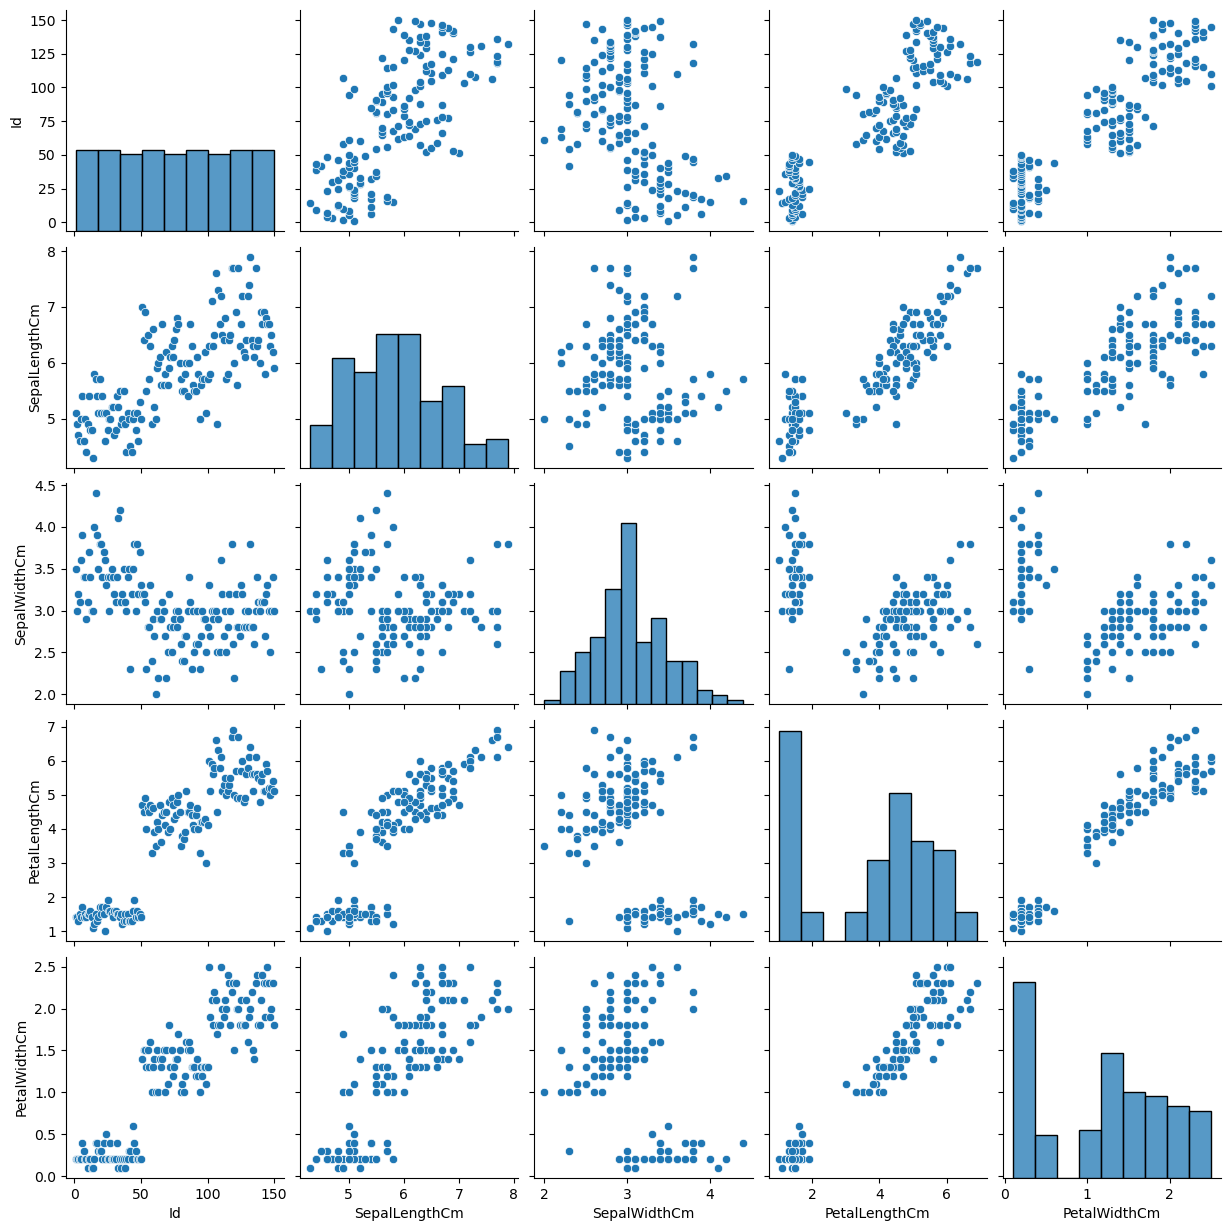

In [10]:
sns.pairplot(df)
plt.show()

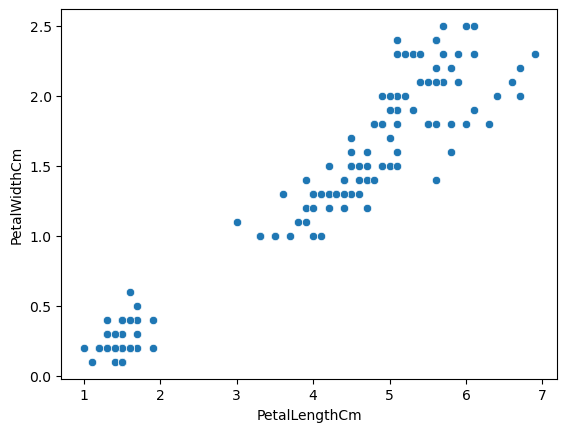

In [54]:
sns.scatterplot(x=df["PetalLengthCm"], y=df["PetalWidthCm"])
plt.show()

In [11]:
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

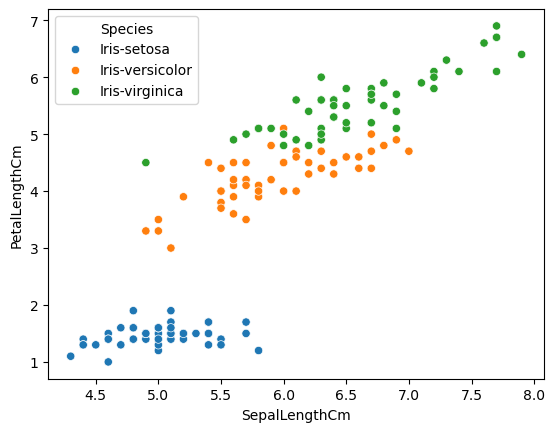

In [13]:
sns.scatterplot(x=df["SepalLengthCm"], y=df["PetalLengthCm"], hue=df["Species"])
plt.show()

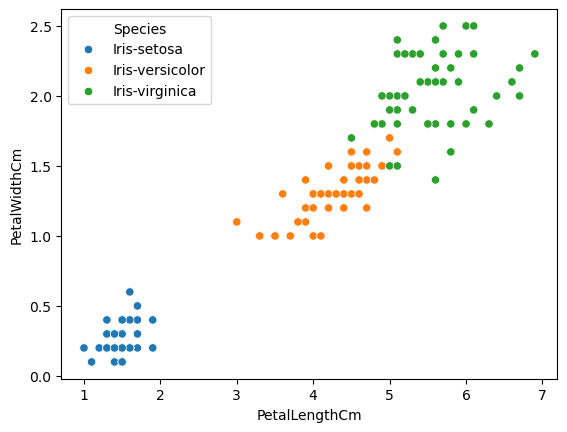

In [14]:
sns.scatterplot(x=df["PetalLengthCm"], y=df["PetalWidthCm"], hue=df["Species"])
plt.show()

In [15]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [16]:
df = df.drop("Id",axis=1)

In [17]:
from sklearn.preprocessing import LabelEncoder

In [19]:
label_encoder = LabelEncoder()
df["Species"] = label_encoder.fit_transform(df["Species"])

In [20]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [21]:
df.tail()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [22]:
df["Species"].value_counts()

Species
0    50
1    50
2    50
Name: count, dtype: int64

In [23]:
X = df.drop("Species", axis=1)
y = df["Species"]

In [24]:
from sklearn.model_selection import train_test_split

In [29]:
X_train,X_test,y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=15)

In [30]:
from sklearn.preprocessing import StandardScaler

In [31]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
from sklearn.naive_bayes import GaussianNB

In [33]:
gnb = GaussianNB()

In [34]:
gnb.fit(X_train_scaled,y_train)
y_pred = gnb.predict(X_test_scaled)

In [35]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [37]:
print("confusion matrix: \n", confusion_matrix(y_pred, y_test))
print("accuracy score ", accuracy_score(y_pred, y_test))
print("classification report", classification_report(y_pred, y_test))

confusion matrix: 
 [[12  0  0]
 [ 0 14  0]
 [ 0  0 12]]
accuracy score  1.0
classification report               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



In [38]:
from sklearn.linear_model import LogisticRegression

In [40]:
logistic = LogisticRegression()
logistic.fit(X_train,y_train)
y_pred = logistic.predict(X_test)

In [41]:
y_pred

array([0, 1, 1, 0, 0, 1, 2, 1, 1, 2, 2, 1, 1, 1, 2, 0, 1, 2, 0, 2, 1, 0,
       1, 1, 0, 0, 2, 2, 2, 1, 0, 2, 1, 2, 0, 0, 2, 0])

In [42]:
score = accuracy_score(y_pred,y_test)
print("score:",score)
print(classification_report(y_pred,y_test))
print("confusion matrix: \n", confusion_matrix(y_pred,y_test))

score: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38

confusion matrix: 
 [[12  0  0]
 [ 0 14  0]
 [ 0  0 12]]


In [43]:
from sklearn.svm import SVC

In [44]:
svc = SVC(kernel = "linear")

In [45]:
svc.fit(X_train,y_train)

SVC(kernel='linear')

In [46]:
svc.coef_

array([[-0.0696746 ,  0.45565922, -0.8596698 , -0.35117643],
       [-0.00684736,  0.1787961 , -0.538554  , -0.29198479],
       [ 0.6175233 ,  1.03154154, -1.92122593, -1.99464758]])

In [47]:
y_pred = svc.predict(X_test)

In [48]:
print(classification_report(y_pred,y_test))
print(confusion_matrix(y_pred, y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.96        13
           2       1.00      0.92      0.96        13

    accuracy                           0.97        38
   macro avg       0.98      0.97      0.97        38
weighted avg       0.98      0.97      0.97        38

[[12  0  0]
 [ 0 13  0]
 [ 0  1 12]]


In [49]:
rbf = SVC(kernel= "rbf")
rbf.fit(X_train, y_train)
y_pred = rbf.predict(X_test)
print(classification_report(y_pred,y_test))
print(confusion_matrix(y_pred, y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      0.93      0.97        15
           2       0.92      1.00      0.96        11

    accuracy                           0.97        38
   macro avg       0.97      0.98      0.97        38
weighted avg       0.98      0.97      0.97        38

[[12  0  0]
 [ 0 14  1]
 [ 0  0 11]]


In [50]:
linear = SVC(kernel = "linear")
linear.fit(X_train,y_train)
y_pred3 = linear.predict(X_test)
print(classification_report(y_pred3,y_test))
print(confusion_matrix(y_pred3, y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.96        13
           2       1.00      0.92      0.96        13

    accuracy                           0.97        38
   macro avg       0.98      0.97      0.97        38
weighted avg       0.98      0.97      0.97        38

[[12  0  0]
 [ 0 13  0]
 [ 0  1 12]]


In [51]:
rbf = SVC(kernel = "rbf")
rbf.fit(X_train,y_train)
y_pred4 = rbf.predict(X_test)
print(classification_report(y_pred4,y_test))
print(confusion_matrix(y_pred4, y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      0.93      0.97        15
           2       0.92      1.00      0.96        11

    accuracy                           0.97        38
   macro avg       0.97      0.98      0.97        38
weighted avg       0.98      0.97      0.97        38

[[12  0  0]
 [ 0 14  1]
 [ 0  0 11]]


In [52]:
poly = SVC(kernel = "poly")
poly.fit(X_train,y_train)
y_pred5 = poly.predict(X_test)
print(classification_report(y_pred5,y_test))
print(confusion_matrix(y_pred5, y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.96        13
           2       1.00      0.92      0.96        13

    accuracy                           0.97        38
   macro avg       0.98      0.97      0.97        38
weighted avg       0.98      0.97      0.97        38

[[12  0  0]
 [ 0 13  0]
 [ 0  1 12]]


In [53]:
sigmoid = SVC(kernel = "sigmoid")
sigmoid.fit(X_train,y_train)
y_pred6 = sigmoid.predict(X_test)
print(classification_report(y_pred6, y_test))
print(confusion_matrix(y_pred6, y_test))

              precision    recall  f1-score   support

           0       0.17      0.08      0.11        25
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00        13

    accuracy                           0.05        38
   macro avg       0.06      0.03      0.04        38
weighted avg       0.11      0.05      0.07        38

[[ 2 11 12]
 [ 0  0  0]
 [10  3  0]]


/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [55]:
from sklearn.preprocessing import StandardScaler

In [56]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [57]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Mean absolute error: 0.15722608545760455
Mean squared error: 0.0417324331988028
R2 score: 0.9339236474352289


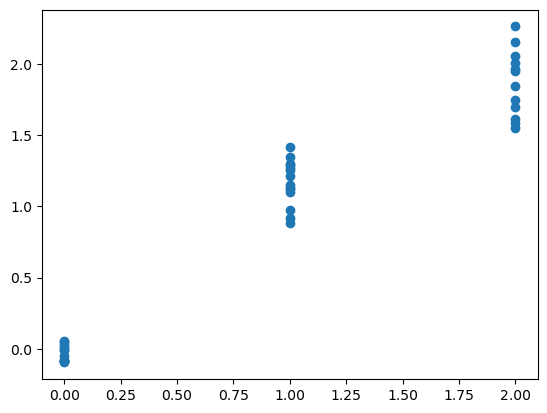

In [58]:
linear = LinearRegression()
linear.fit(X_train_scaled,y_train)
y_pred = linear.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("Mean absolute error:",mae)
print("Mean squared error:",mse)
print("R2 score:",score)
plt.scatter(y_test,y_pred)
plt.show()

In [59]:
from sklearn.svm import SVR

Mean absolute error: 0.13709222254309403
Mean squared error: 0.029810360880130365
R2 score: 0.9528002619397936


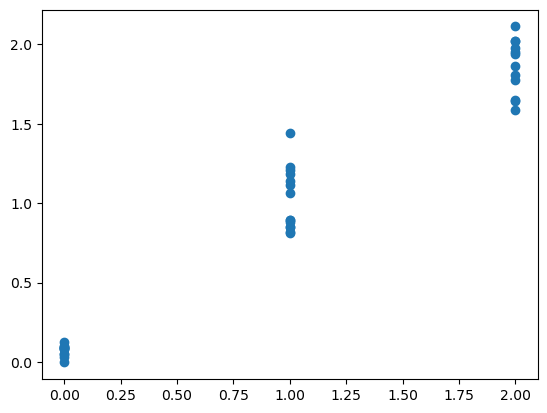

In [60]:
svr = SVR()
svr.fit(X_train_scaled,y_train)
y_pred = svr.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("Mean absolute error:",mae)
print("Mean squared error:",mse)
print("R2 score:",score)
plt.scatter(y_test,y_pred)
plt.show()

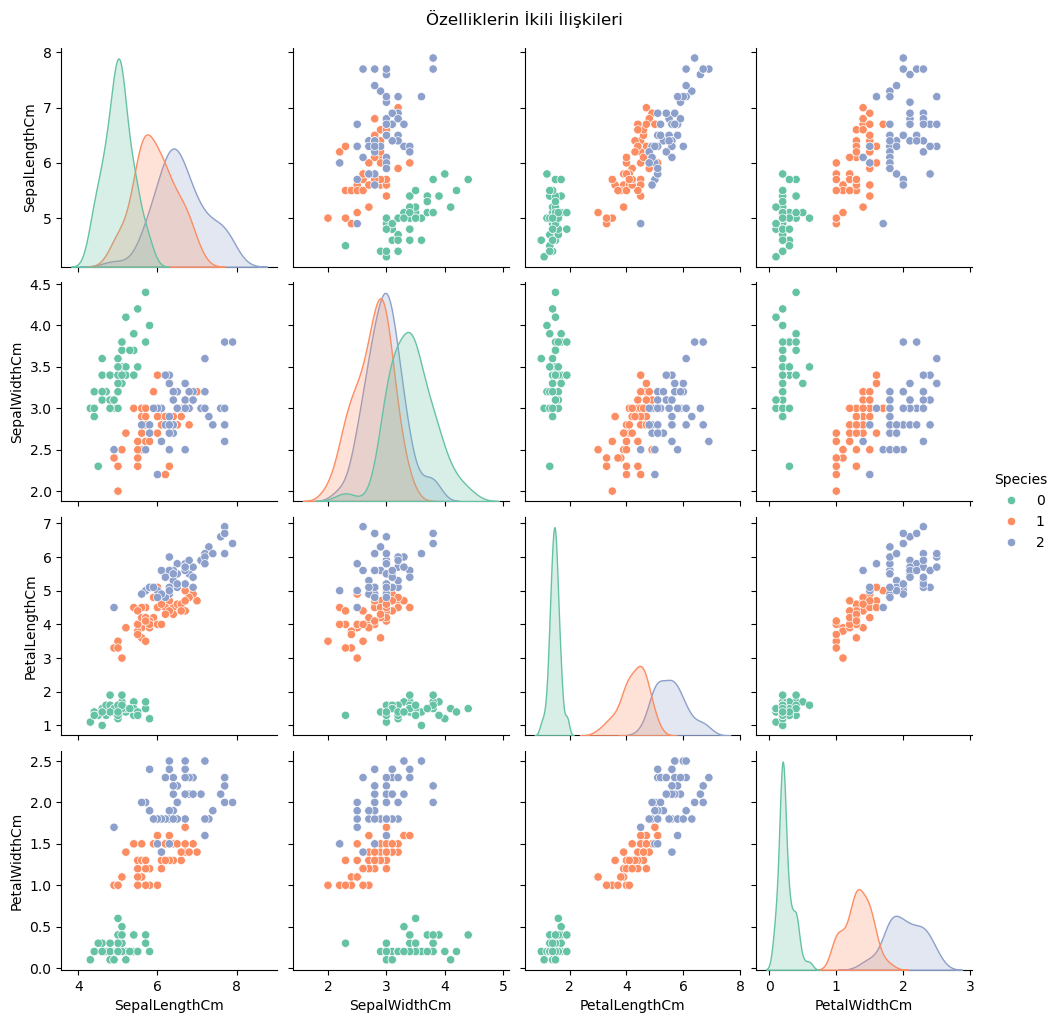

In [61]:
sns.pairplot(df, hue="Species", palette="Set2")
plt.suptitle("Özelliklerin İkili İlişkileri", y=1.02)
plt.show()

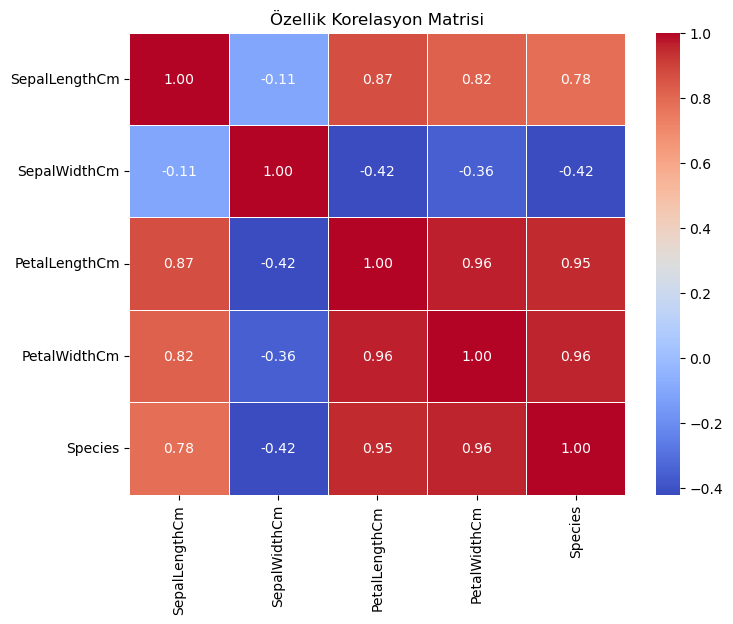

In [62]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Özellik Korelasyon Matrisi")
plt.show()

In [63]:
log_reg = LogisticRegression(max_iter=200) 
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=200)

In [64]:
y_pred_log = log_reg.predict(X_test_scaled)

In [65]:
print("=== LOJİSTİK REGRESYON SONUÇLARI ===")
print("Sınıflandırma Raporu:")
print(classification_report(y_test, y_pred_log))

=== LOJİSTİK REGRESYON SONUÇLARI ===
Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



In [66]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

Confusion Matrix:
[[12  0  0]
 [ 0 14  0]
 [ 0  0 12]]
